In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the Titanic dataset
df = pd.read_csv('titanic_dataset_clean.csv')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  embark_town  891 non-null    object 
 12  alive        891 non-null    object 
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(6)
memory usage: 85.4+ KB


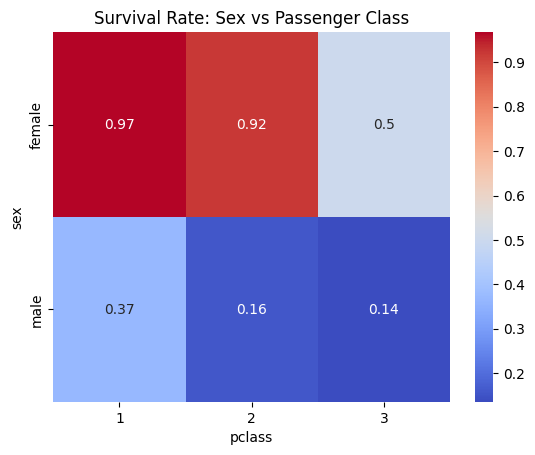

In [3]:
pivot = df.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Survival Rate: Sex vs Passenger Class')
plt.show()

In [ ]:
#here this heatmap shows that female passengers in first class had the highest survival rate, 
# while male passengers in third class had the lowest survival rate. 
# This suggests that both gender and passenger class played a significant role in determining 
# the likelihood of survival on the Titanic.

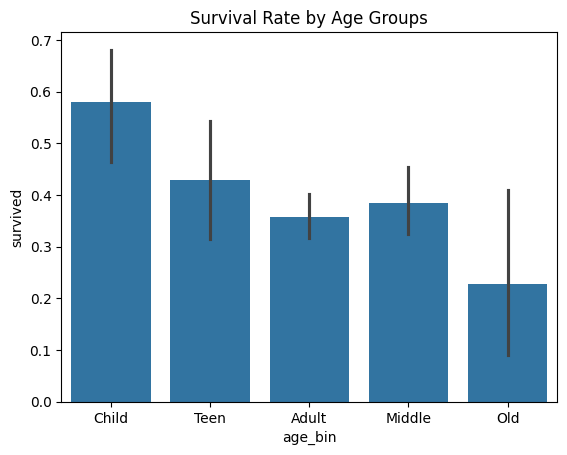

In [6]:
df['age_bin'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child','Teen','Adult','Middle','Old'])

sns.barplot(x='age_bin', y='survived', data=df)
plt.title('Survival Rate by Age Groups')
plt.show()

In [ ]:
#here we can see that child is the age group wiht the highest survival rate


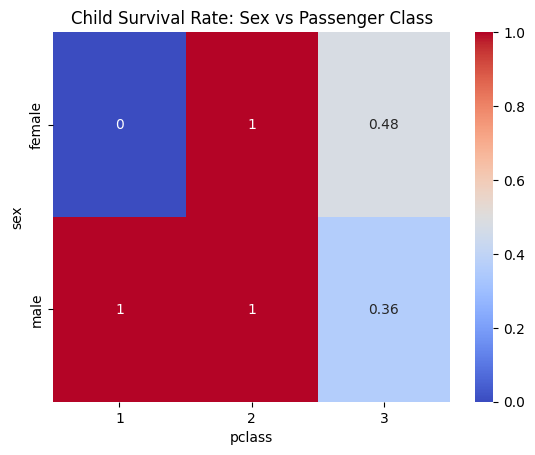

In [7]:
# S Create age groups
df['age_bin'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child','Teen','Adult','Middle','Old']
)

#  Filter only children
child_df = df[df['age_bin'] == 'Child']

#  Pivot table (Sex vs Class)
pivot_child = child_df.pivot_table(
    values='survived',
    index='sex',
    columns='pclass',
    aggfunc='mean'
)

# : Heatmap
sns.heatmap(pivot_child, annot=True, cmap='coolwarm')

plt.title('Child Survival Rate: Sex vs Passenger Class')
plt.show()

In [ ]:
# here we can see that a higher portion of male children in first class survived compared to 
# female children in first class ,in second class all of the children survived regardless of gender, 
# and in third class was alomost the same for both male and female children, with a slightly higher survival rate 
# for female children. This suggests that while passenger class had a significant impact on survival rates for
# children. 

In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'age_bin'],
      dtype='object')

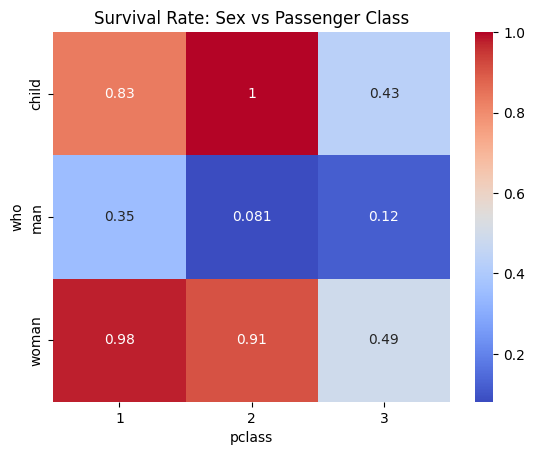

In [9]:
pivot = df.pivot_table(values='survived', index='who', columns='pclass', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Survival Rate: Sex vs Passenger Class')
plt.show()

In [ ]:
# here we can see that a women in first class, second class and  second class child were almost 100% likely to survive.
# while male in second class alomost 100% likely to not survive. 